# Día 4 · Cuaderno 11 — Más pipelines con IA y diseño pedagógico

**Programar para enseñar — Python e IA generativa para Humanidades Digitales**
Formación docente para EH1023 · Pontificia Universidad Javeriana, Facultad de Ingeniería

*(Segundo bloque del Día 4 — 2 horas)*

---

Esta mañana aprendiste el método: **capturar → procesar → visualizar**, con prompts cortos y
verificación. Ahora vamos a (1) **practicarlo con más ejemplos** inspirados en sus proyectos de la
encuesta, y (2) pensar **cómo llevar la IA al aula** con criterio: políticas de uso y evaluación.


## 1. Pipeline 3 — Fechas históricas (procesar fechas y agrupar por siglo)

Mismo método, datos distintos. Aquí la parte interesante es el **procesamiento**: convertir años en
siglos.

### Paso 1 · Capturar
> *En Python con pandas, carga este CSV en un DataFrame `df` y muéstralo:*
> `.../datos/fechas_historicas.csv`


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/fechas_historicas.csv"
df = pd.read_csv(url)
df

,evento,anio
0,Fundacion de Tenochtitlan,1325
1,Llegada de Colon a America,1492
2,Independencia de Mexico,1821
3,Revolucion Mexicana,1910
4,Fundacion del Tecnologico de Monterrey,1943


### Paso 2 · Procesar
> *Crea una columna nueva `siglo` calculada a partir de la columna `anio`
> (siglo = (anio - 1) // 100 + 1) y cuenta cuántos eventos hay por siglo.*


In [2]:
df["siglo"] = (df["anio"] - 1) // 100 + 1
conteo_siglo = df["siglo"].value_counts().sort_index()
print(conteo_siglo)

siglo
14    1
15    1
19    1
20    2
Name: count, dtype: int64


### Paso 3 · Visualizar
> *Haz un gráfico de barras de eventos por siglo, con etiquetas en español.*


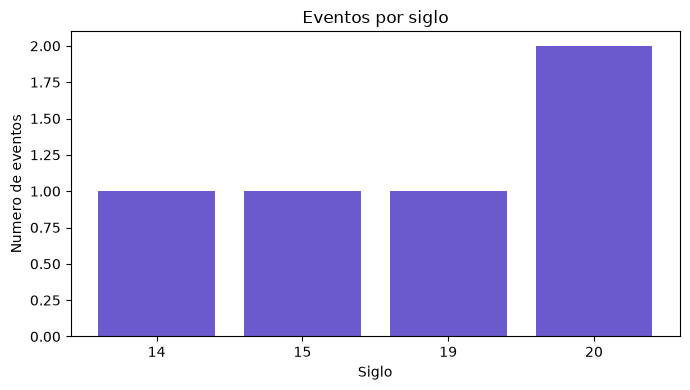

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(conteo_siglo.index.astype(str), conteo_siglo.values, color="slateblue")
plt.title("Eventos por siglo")
plt.xlabel("Siglo")
plt.ylabel("Numero de eventos")
plt.tight_layout()
plt.show()

## 2. Pipeline 4 — Obras a lo largo del tiempo (variación temporal)

Varios de ustedes mencionaron querer ver **cómo cambian los datos en el tiempo**. Reusamos el catálogo
de obras y las agrupamos por **década**.

### Paso 1 · Capturar


In [4]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/obras_literarias.csv")
df.head()

,titulo,autor,anio,genero,paginas
0,Don Quijote de la Mancha,Miguel de Cervantes,1605,Novela,863
1,La vida es sueno,Pedro Calderon de la Barca,1635,Teatro,120
2,Cien anios de soledad,Gabriel Garcia Marquez,1967,Novela,471
3,Pedro Paramo,Juan Rulfo,1955,Novela,124
4,Rayuela,Julio Cortazar,1963,Novela,736


### Paso 2 · Procesar
> *Agrupa las obras por década (el año redondeado a la decena inferior) y cuenta cuántas hay en cada una.*


In [5]:
df["decada"] = (df["anio"] // 10) * 10
obras_por_decada = df["decada"].value_counts().sort_index()
print(obras_por_decada)

decada
1600    1
1630    1
1910    1
1920    2
1930    3
1940    6
1950    5
1960    5
1970    1
1980    3
1990    2
Name: count, dtype: int64


### Paso 3 · Visualizar
> *Haz un gráfico de líneas con el número de obras por década.*


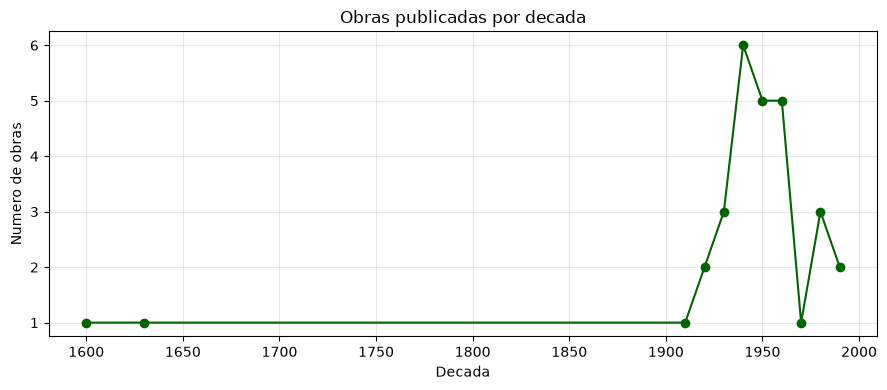

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(obras_por_decada.index, obras_por_decada.values, marker="o", color="darkgreen")
plt.title("Obras publicadas por decada")
plt.xlabel("Decada")
plt.ylabel("Numero de obras")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Galería de pipelines según sus intereses

Estos son proyectos que ustedes mencionaron en la encuesta, ya **descompuestos en una secuencia de 3
prompts**. Son plantillas: llévalas a Gemini, Copilot o TecGPT, adáptalas a tus datos y verifícalas.

### A) Análisis de las voces de un personaje (texto literario / guion)
1. **Capturar:** *"Carga el texto de esta URL en una variable y sepáralo en las líneas de diálogo de un personaje."*
2. **Procesar:** *"Cuenta las palabras más frecuentes y la longitud promedio de sus intervenciones."*
3. **Visualizar:** *"Grafica en barras sus 10 palabras más usadas."*

### B) Visualización de una playlist / catálogo musical (CSV)
1. **Capturar:** *"Carga este CSV de canciones (titulo, artista, anio, genero, duracion) en un DataFrame."*
2. **Procesar:** *"Cuenta cuántas canciones hay por género y la duración promedio por género."*
3. **Visualizar:** *"Haz un gráfico de barras de canciones por género."*

### C) Numeralia de una facultad o programa (datos institucionales)
1. **Capturar:** *"Carga este CSV con datos por año (matriculados, egresados) en un DataFrame."*
2. **Procesar:** *"Calcula el total por año y la variación respecto al año anterior."*
3. **Visualizar:** *"Haz un gráfico de líneas de la evolución por año."*

### D) Cobertura de un tema en prensa / redes (texto)
1. **Capturar:** *"Carga este archivo de titulares en una lista, una línea por titular."*
2. **Procesar:** *"Cuenta cuántos titulares mencionan cada una de estas palabras clave: [...]."*
3. **Visualizar:** *"Haz un gráfico de barras con la frecuencia de cada palabra clave."*

> 🔭 **Ideas más ambiciosas** (redes de personajes, análisis de sentimiento, scrollytelling): son
> excelentes proyectos finales, pero requieren librerías adicionales (como `networkx`). Guárdalas para
> el Día 5 y el proyecto integrador; hoy consolidamos el método con pipelines alcanzables.


## 4. Actividad — arma y ejecuta tu pipeline

Toma **una** de las plantillas de arriba (o tu propia idea de la mañana) y llévala a la práctica:

1. Escribe tus **3 prompts cortos**.
2. Pégalos uno a uno en Gemini / Copilot / TecGPT.
3. Trae el código a las celdas de abajo, ejecútalo y **verifica cada paso**.


In [9]:
# Paso 1 - Capturar (pega aqui el codigo de la IA):
import requests
from collections import Counter
from stopwordsiso import stopwords


# Cargar el texto desde la URL
url = "https://raw.githubusercontent.com/juancbaena/curso-python-humanidades-digitales/main/dia-4/La%20gallina%20degollada.txt"
response = requests.get(url)

if response.status_code == 200:
    texto = response.text
else:
    raise Exception(f"No se pudo cargar el texto. Código de estado: {response.status_code}")

# Separar los diálogos (marcados por el símbolo —) y el resto del texto
dialogos = []
texto_no_dialogos = []

# Dividir el texto en líneas
lineas = texto.split('\n')

for linea in lineas:
    linea = linea.strip()  # Eliminar espacios en blanco en los extremos
    if linea.startswith('—'):  # Identificar líneas de diálogo
        dialogos.append(linea)
    else:
        texto_no_dialogos.append(linea)

# Convertir las listas en cadenas de texto separadas por saltos de línea
dialogos_texto = '\n'.join(dialogos)
texto_no_dialogos_texto = '\n'.join(texto_no_dialogos)

# Imprimir los resultados
print("Diálogos:")
print(dialogos_texto)
print("\nTexto no relacionado con diálogos:")
print(texto_no_dialogos_texto)

Diálogos:
—¡Hijo, mi hijo querido! —sollozaba ésta, sobre aquella espantosa ruina de su primogénito.
—A usted se le puede decir: creo que es un caso perdido. Podrá mejorar, educarse en todo lo que le permita su idiotismo, pero no más allá.
—¡Sí!… ¡Sí! —asentía Mazzini—. Pero dígame: ¿Usted cree que es herencia, que…?
—En cuanto a la herencia paterna, ya le dije lo que creía cuando vi a su hijo. Respecto a la madre, hay allí un pulmón que no sopla bien. No veo nada más, pero hay un soplo un poco rudo. Hágala examinar detenidamente.
—Me parece —díjole una noche Mazzini, que acababa de entrar y se lavaba las manos—que podrías tener más limpios a los muchachos.
—Es la primera vez —repuso al rato— que te veo inquietarte por el estado de tus hijos.
—De nuestros hijos, ¿me parece?
—Bueno, de nuestros hijos. ¿Te gusta así? —alzó ella los ojos.
—¿Creo que no vas a decir que yo tenga la culpa, no?
—¡Ah, no! —se sonrió Berta, muy pálida— ¡pero yo tampoco, supongo!… ¡No faltaba más!… —murmuró.
—¿Q

In [11]:
# Paso 2 - Procesar:
def contar_palabras_frecuentes(texto, stopwords_lista, top_n=10):
    # Dividir el texto en palabras
    palabras = texto.lower().split()
    # Filtrar palabras vacías
    palabras_filtradas = [palabra.strip('.,!?¡¿"\'()[]') for palabra in palabras if palabra not in stopwords_lista]
    # Contar frecuencias
    frecuencias = Counter(palabras_filtradas)
    # Obtener las palabras más frecuentes
    return frecuencias.most_common(top_n)
    
# Obtener las palabras vacías en español
stopwords_es = stopwords("es")

# Contar palabras más frecuentes en diálogos y texto no relacionado con diálogos
palabras_frecuentes_dialogos = contar_palabras_frecuentes(dialogos_texto, stopwords_es)
palabras_frecuentes_no_dialogos = contar_palabras_frecuentes(texto_no_dialogos_texto, stopwords_es)

# Imprimir los resultados
print("Palabras más frecuentes en los diálogos:")
print(palabras_frecuentes_dialogos)

print("\nPalabras más frecuentes en el texto no relacionado con diálogos:")
print(palabras_frecuentes_no_dialogos)

Palabras más frecuentes en los diálogos:
[('no', 6), ('hijos', 5), ('más', 3), ('culpa', 3), ('padre', 3), ('víbora', 3), ('cocina', 3), ('hijo', 2), ('sí', 2), ('herencia', 2)]

Palabras más frecuentes en el texto no relacionado con diálogos:
[('mazzini', 14), ('berta', 13), ('amor', 9), ('hijo', 9), ('idiotas', 8), ('cerco', 8), ('banco', 7), ('padres', 6), ('hijos', 5), ('ojos', 5)]


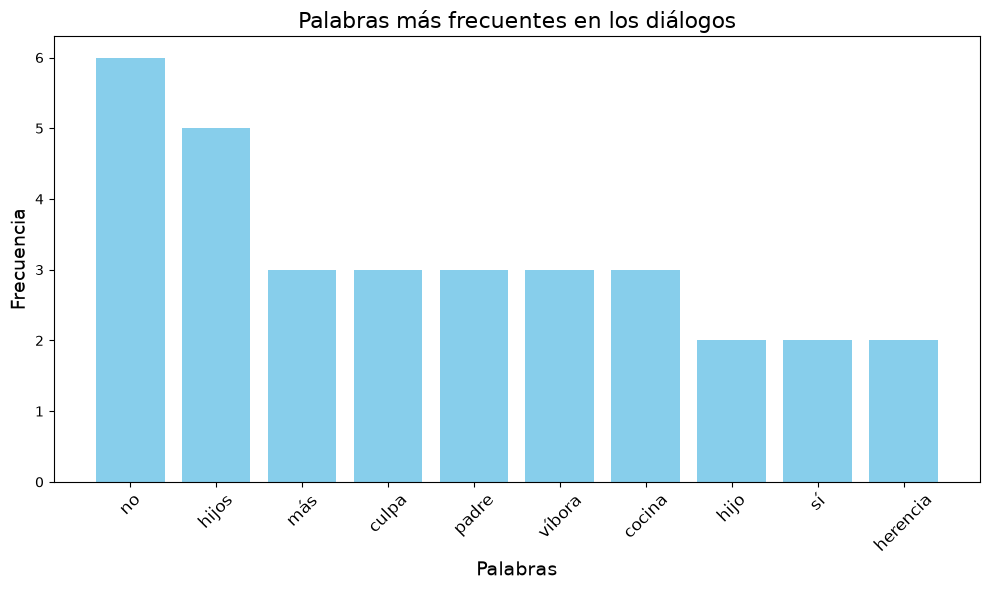

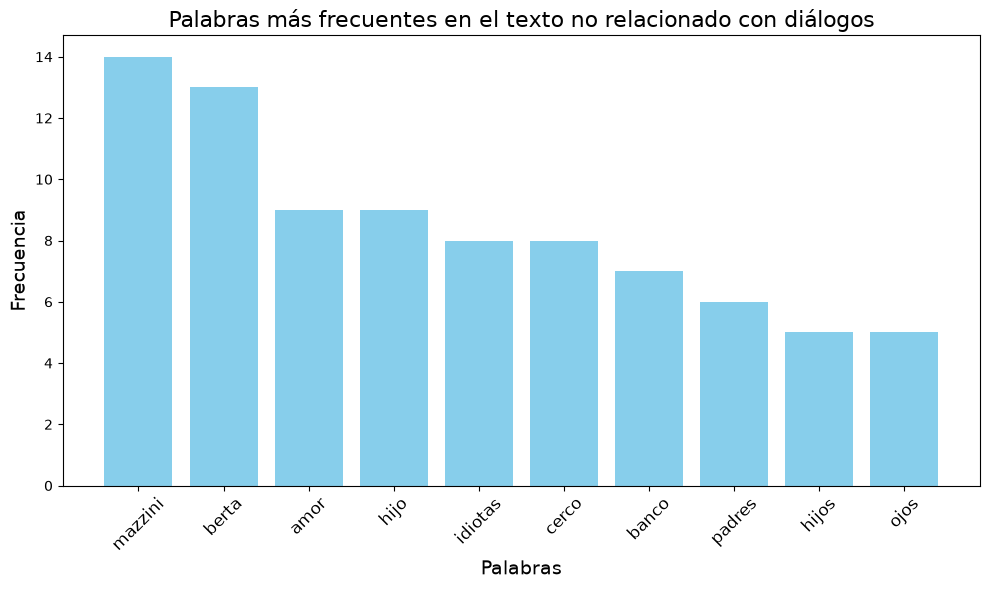

In [12]:
# Paso 3 - Visualizar:
import matplotlib.pyplot as plt
# Función para graficar las palabras más frecuentes
def graficar_palabras_frecuentes(palabras_frecuentes, titulo):
    palabras, frecuencias = zip(*palabras_frecuentes)
    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color='skyblue')
    plt.title(titulo, fontsize=16)
    plt.xlabel("Palabras", fontsize=14)
    plt.ylabel("Frecuencia", fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.tight_layout()
    plt.show()

# Graficar las palabras más frecuentes en los diálogos
graficar_palabras_frecuentes(palabras_frecuentes_dialogos, "Palabras más frecuentes en los diálogos")

# Graficar las palabras más frecuentes en el texto no relacionado con diálogos
graficar_palabras_frecuentes(palabras_frecuentes_no_dialogos, "Palabras más frecuentes en el texto no relacionado con diálogos")

## 5. Llevar la IA al aula: política de uso

Como docente, conviene **declarar reglas claras** sobre la IA desde el inicio del curso. Un espectro útil:

| Nivel | Regla | Cuándo conviene |
|---|---|---|
| **Prohibida** | No se permite IA en esta tarea | Cuando se evalúa un fundamento que deben dominar solos |
| **Permitida con reglas** | Se puede usar, pero hay que **declarar** qué se pidió y **explicar** el código | La mayoría de las actividades del EH1023 |
| **Libre** | Uso abierto | Proyectos exploratorios o avanzados |

La opción del medio suele ser la más formativa: el estudiante usa la IA **y** demuestra que entiende.

> 🧭 La pregunta clave para diseñar una tarea no es *"¿uso IA o no?"*, sino *"¿qué quiero que el
> estudiante **comprenda**, y cómo me aseguro de verlo?"*.


## 6. Evaluar trabajos hechos con IA: una rúbrica breve

Responde a otra preocupación frecuente de la encuesta: *no saber evaluar trabajos hechos con IA*. La
clave es **evaluar el proceso y la comprensión, no solo el resultado**.

| Criterio | Qué observar | Peso sugerido |
|---|---|---|
| **Descomposición del problema** | ¿Partió el problema en pasos claros? | 25% |
| **Calidad de los prompts** | ¿Fueron específicos y verificables? | 20% |
| **Comprensión del código** | ¿Puede explicar qué hace cada parte? | 30% |
| **Verificación** | ¿Detectó y corrigió errores de la IA? | 15% |
| **Resultado** | ¿El pipeline funciona y responde la pregunta? | 10% |

Fíjate que el **resultado** pesa poco: con IA, cualquiera obtiene "algo que corre". Lo valioso es que
el estudiante **entienda y verifique**.


## 7. Tu turno (diseño docente)

Elige un tema del EH1023 y redacta:

- **La política de uso de IA** que pondrías para esa actividad (de las tres del espectro).
- **Una pregunta o tarea** que un estudiante resolvería con un pipeline de 3 prompts.
- **Cómo verificarías** que comprende y no solo copió (p. ej., pedirle que explique una línea, o que
  cambie un parámetro y prediga el resultado).


**Plantilla**

- **Tema del EH1023:**
- **Política de uso de IA:**
- **Tarea (pipeline de 3 pasos):**
- **Cómo evaluaré la comprensión:**


> 🧭 **Nota para docentes.** Ten estas dos tablas (política y rúbrica) listas para tu curso: son
> material reutilizable directo para el EH1023. Y recuerda el hilo de la semana: **ustedes delimitan
> el taller**. Una primera tarea con IA debe ser **alcanzable y verificable**; el reto mayor llega
> cuando los estudiantes ya saben descomponer y verificar.


---

## Cierre del Día 4

Hoy aprendiste a **programar con IA de forma crítica y metódica**: descomponer en una secuencia de
prompts cortos (capturar → procesar → visualizar), **verificar** cada paso, y **llevarlo al aula** con
una política de uso y una rúbrica centradas en la comprensión.

### Mañana (Día 5)

Cerramos el curso: **APIs y extracción de información de la web**, una mirada a los **medios digitales**,
y el **proyecto integrador** para el EH1023, donde reunirás todo lo de la semana.

> Guarda tu trabajo con **Archivo → Guardar una copia en Drive**. ¡Gran avance hoy!
